# 05_03 · Modelos Avanzados — KIT Industrial

Búsqueda de hiperparámetros con LOO-CV sobre el dataset KIT (n=33).

Estrategia: para cada configuración, evaluamos con Leave-One-Out sobre los 33 experimentos.
No hay train/test fijo — LOO es el único método válido con tan pocos datos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os, warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneOut, cross_val_score, cross_val_predict
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, roc_auc_score, classification_report

import sys; sys.path.insert(0, '../../src')
from paths import PROCESSED as PROC_DIR, MODELS as MODEL_DIR
os.makedirs(MODEL_DIR, exist_ok=True)

df = pd.read_csv(os.path.join(PROC_DIR, 'industrial_features_v2.csv'))
feat_cols = [c for c in df.columns
             if c not in ('trial','fault_type','fault_name','anomaly','n_samples')]
X_raw = df[feat_cols].values
y     = df['anomaly'].values

print(f'Experimentos: {len(df)} | Features: {len(feat_cols)}')
print(f'Normal: {(y==0).sum()} | Anomalía: {(y==1).sum()}')

Experimentos: 33 | Features: 224
Normal: 18 | Anomalía: 15


## 1. Preprocesado base

Pipeline fijo: `VarianceThreshold` → `SelectKBest(k=30)` → `StandardScaler`.
Aplicado dentro de LOO para evitar data leakage.

In [2]:
from sklearn.pipeline import Pipeline

def make_pipe(clf, k=30):
    return Pipeline([
        ('var',  VarianceThreshold(threshold=0.0)),
        ('sel',  SelectKBest(f_classif, k=k)),
        ('sc',   StandardScaler()),
        ('clf',  clf),
    ])

loo = LeaveOneOut()

def loo_f1(pipe):
    y_pred = cross_val_predict(pipe, X_raw, y, cv=loo)
    return f1_score(y, y_pred, zero_division=0)

def loo_auc(pipe):
    # AUC requiere predict_proba o decision_function
    try:
        scores = cross_val_predict(pipe, X_raw, y, cv=loo, method='predict_proba')[:,1]
    except AttributeError:
        scores = cross_val_predict(pipe, X_raw, y, cv=loo, method='decision_function')
    return roc_auc_score(y, scores)

# Referencia: RF por defecto
ref = make_pipe(RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42))
f1_ref = loo_f1(ref)
print(f'Referencia RF (n_estimators=200): F1={f1_ref:.3f}')

Referencia RF (n_estimators=200): F1=0.600


## 2. Búsqueda de hiperparámetros — Random Forest

In [3]:
rf_grid = [
    {'n_estimators': n, 'max_depth': d, 'min_samples_leaf': l,
     'class_weight': cw, 'random_state': 42}
    for n  in [100, 200, 500]
    for d  in [None, 5, 10]
    for l  in [1, 2, 3]
    for cw in ['balanced', 'balanced_subsample']
]

rf_results = []
for params in rf_grid:
    pipe = make_pipe(RandomForestClassifier(**params))
    f1  = loo_f1(pipe)
    rf_results.append({**params, 'F1': f1})

rf_df = pd.DataFrame(rf_results).sort_values('F1', ascending=False)
print("Top 10 RF:")
print(rf_df.head(10).to_string(index=False))

Top 10 RF:
 n_estimators  max_depth  min_samples_leaf       class_weight  random_state       F1
          200        5.0                 2 balanced_subsample            42 0.666667
          500        5.0                 1           balanced            42 0.666667
          200       10.0                 2 balanced_subsample            42 0.666667
          500        NaN                 1           balanced            42 0.666667
          500       10.0                 1           balanced            42 0.666667
          200        NaN                 2 balanced_subsample            42 0.666667
          500        NaN                 1 balanced_subsample            42 0.645161
          500        NaN                 2 balanced_subsample            42 0.645161
          500        NaN                 3           balanced            42 0.645161
          500        NaN                 3 balanced_subsample            42 0.645161


## 3. Búsqueda de hiperparámetros — Gradient Boosting

In [4]:
gb_grid = [
    {'n_estimators': n, 'learning_rate': lr, 'max_depth': d,
     'subsample': ss, 'random_state': 42}
    for n  in [50, 100, 200]
    for lr in [0.05, 0.1, 0.3]
    for d  in [2, 3, 4]
    for ss in [0.8, 1.0]
]

gb_results = []
for params in gb_grid:
    pipe = make_pipe(GradientBoostingClassifier(**params))
    f1  = loo_f1(pipe)
    gb_results.append({**params, 'F1': f1})

gb_df = pd.DataFrame(gb_results).sort_values('F1', ascending=False)
print("Top 10 GB:")
print(gb_df.head(10).to_string(index=False))

Top 10 GB:
 n_estimators  learning_rate  max_depth  subsample  random_state       F1
          200           0.30          4        0.8            42 0.733333
          100           0.10          4        0.8            42 0.733333
          100           0.30          4        0.8            42 0.733333
          100           0.30          2        0.8            42 0.709677
          100           0.05          3        0.8            42 0.709677
          100           0.05          4        0.8            42 0.689655
          200           0.05          4        0.8            42 0.689655
          200           0.10          4        0.8            42 0.689655
          200           0.10          3        0.8            42 0.687500
          200           0.05          3        0.8            42 0.687500


## 4. Búsqueda de hiperparámetros — SVM

In [5]:
svm_grid = [
    {'C': c, 'kernel': k, 'gamma': g, 'class_weight': 'balanced', 'probability': True}
    for c in [0.1, 1, 10, 100]
    for k in ['rbf', 'linear']
    for g in ['scale', 'auto']
    if not (k == 'linear' and g == 'auto')  # linear ignora gamma
]

svm_results = []
for params in svm_grid:
    pipe = make_pipe(SVC(**params))
    f1  = loo_f1(pipe)
    try:
        auc = loo_auc(make_pipe(SVC(**params)))
    except Exception:
        auc = np.nan
    svm_results.append({**params, 'F1': f1, 'AUC': auc})

svm_df = pd.DataFrame(svm_results).sort_values('F1', ascending=False)
print("Top 10 SVM:")
print(svm_df[['C','kernel','gamma','F1','AUC']].head(10).to_string(index=False))

Top 10 SVM:
    C kernel gamma       F1      AUC
  1.0 linear scale 0.666667 0.692593
100.0 linear scale 0.645161 0.637037
 10.0 linear scale 0.625000 0.711111
100.0    rbf scale 0.620690 0.714815
100.0    rbf  auto 0.620690 0.703704
 10.0    rbf scale 0.600000 0.700000
 10.0    rbf  auto 0.600000 0.700000
  1.0    rbf scale 0.571429 0.600000
  1.0    rbf  auto 0.571429 0.633333
  0.1 linear scale 0.444444 0.529630


## 4b. Búsqueda de hiperparámetros — KNN

Con n=33 y distancias en alta dimensión KNN suele sufrir, pero es barato comprobarlo
y completa la comparativa de familias.


In [6]:
knn_grid = [
    {'n_neighbors': k, 'weights': w}
    for k in [3, 5, 7]
    for w in ['uniform', 'distance']
]

knn_results = []
for params in knn_grid:
    pipe = make_pipe(KNeighborsClassifier(**params))
    f1 = loo_f1(pipe)
    knn_results.append({**params, 'F1': f1})

knn_df = pd.DataFrame(knn_results).sort_values('F1', ascending=False)
print("Top KNN:")
print(knn_df.to_string(index=False))
print('\n→ KNN queda por debajo de RF/GB/SVM: la distancia euclídea en 30 dimensiones')
print('  seleccionadas no separa bien con tan pocas muestras por clase.')


Top KNN:
 n_neighbors  weights       F1
           5  uniform 0.666667
           3  uniform 0.642857
           7 distance 0.625000
           3 distance 0.620690
           5 distance 0.606061
           7  uniform 0.533333

→ KNN queda por debajo de RF/GB/SVM: la distancia euclídea en 30 dimensiones
  seleccionadas no separa bien con tan pocas muestras por clase.


## 5. Comparativa y modelo ganador

                   Modelo       F1
Gradient Boosting (tuned) 0.733333
    Random Forest (tuned) 0.666667
              SVM (tuned) 0.666667
              KNN (tuned) 0.666667
      RF baseline (n=200) 0.600000


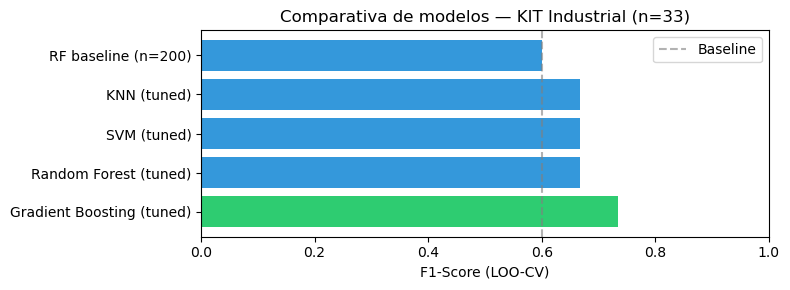

In [7]:
best_rf  = rf_df.iloc[0]
best_gb  = gb_df.iloc[0]
best_svm = svm_df.iloc[0]
best_knn = knn_df.iloc[0]

summary = pd.DataFrame([
    {'Modelo': 'Random Forest (tuned)',      'F1': best_rf['F1']},
    {'Modelo': 'Gradient Boosting (tuned)',  'F1': best_gb['F1']},
    {'Modelo': 'SVM (tuned)',                'F1': best_svm['F1']},
    {'Modelo': 'KNN (tuned)',                'F1': best_knn['F1']},
    {'Modelo': 'RF baseline (n=200)',        'F1': f1_ref},
]).sort_values('F1', ascending=False)

print(summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 3))
colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(summary))]
ax.barh(summary['Modelo'], summary['F1'], color=colors)
ax.set_xlim(0, 1)
ax.axvline(f1_ref, color='gray', linestyle='--', alpha=0.6, label='Baseline')
ax.set_xlabel('F1-Score (LOO-CV)')
ax.set_title('Comparativa de modelos — KIT Industrial (n=33)')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Evaluación detallada del mejor modelo

In [8]:
# Reconstruir mejor modelo global
best_row = summary.iloc[0]
best_name = best_row['Modelo']
print(f'Mejor modelo: {best_name} | F1={best_row["F1"]:.3f}')

if 'Random Forest' in best_name and 'baseline' not in best_name:
    best_params = rf_df.iloc[0].drop('F1').to_dict()
    best_params = {k: (None if v != v else (int(v) if isinstance(v, float) and v == int(v) else v))
                   for k, v in best_params.items()}
    best_clf = RandomForestClassifier(**best_params)
elif 'KNN' in best_name:
    best_params = knn_df.iloc[0].drop('F1').to_dict()
    best_params['n_neighbors'] = int(best_params['n_neighbors'])
    best_clf = KNeighborsClassifier(**best_params)
elif 'Gradient' in best_name:
    best_params = gb_df.iloc[0].drop('F1').to_dict()
    best_clf = GradientBoostingClassifier(**{k: int(v) if isinstance(v, float) and v==int(v) else v
                                             for k,v in best_params.items()})
else:
    best_params = svm_df.iloc[0].drop(['F1','AUC']).to_dict()
    best_clf = SVC(**best_params)

best_pipe = make_pipe(best_clf)
y_pred = cross_val_predict(best_pipe, X_raw, y, cv=loo)

print()
print(classification_report(y, y_pred, target_names=['Normal','Anomalía']))

try:
    y_prob = cross_val_predict(best_pipe, X_raw, y, cv=loo, method='predict_proba')[:,1]
    auc = roc_auc_score(y, y_prob)
    print(f'ROC-AUC: {auc:.3f}')
except Exception:
    pass

Mejor modelo: Gradient Boosting (tuned) | F1=0.733

              precision    recall  f1-score   support

      Normal       0.78      0.78      0.78        18
    Anomalía       0.73      0.73      0.73        15

    accuracy                           0.76        33
   macro avg       0.76      0.76      0.76        33
weighted avg       0.76      0.76      0.76        33

ROC-AUC: 0.685


## 7. Construcción del artefacto

La construcción y guardado de `models/kit_model.pkl` vive en
**`06_MODELOS_FINALES/06_02_Modelo_Final_Capa2_Mecanica`**. Si la búsqueda de este
notebook encuentra una configuración mejor que la registrada allí (`KIT_PARAMS`),
actualízala y re-ejecuta el 06_02.
